Accuracy: 0.7662337662337663

Confusion Matrix:
 [[85 14]
 [22 33]]

Classification Report:
               precision    recall  f1-score   support

           0       0.79      0.86      0.83        99
           1       0.70      0.60      0.65        55

    accuracy                           0.77       154
   macro avg       0.75      0.73      0.74       154
weighted avg       0.76      0.77      0.76       154



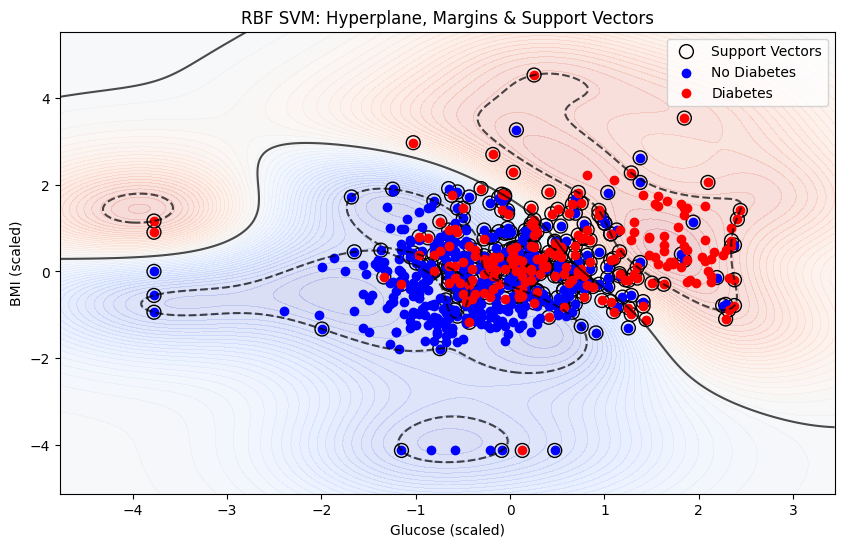

In [1]:

# ===========================================
# SVM Lab: Pima Indians Diabetes Dataset
# Linear Kernel + Hyperplane Visualization
# ===========================================

# Step 1: Import Libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
import matplotlib.pyplot as plt

# Step 2: Load Dataset
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"
columns = ["Pregnancies","Glucose","BloodPressure","SkinThickness","Insulin","BMI",
           "DiabetesPedigreeFunction","Age","Outcome"]
df = pd.read_csv(url, names=columns)

# Step 3: Select 2 Features for Visualization
X = df[["Glucose", "BMI"]].values
y = df["Outcome"].values

# Step 4: Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 5: Feature Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Step 6: Train RBF SVM
svm_classifier = SVC(kernel='rbf', C=1.0, gamma='scale')
svm_classifier.fit(X_train, y_train)

# Step 7: Evaluate Model
y_pred = svm_classifier.predict(X_test)
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Step 8: Create Mesh Grid for Plot
x_min, x_max = X_train[:, 0].min() - 1, X_train[:, 0].max() + 1
y_min, y_max = X_train[:, 1].min() - 1, X_train[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 500),
                     np.linspace(y_min, y_max, 500))

# Step 9: Compute Decision Function
Z = svm_classifier.decision_function(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Step 10: Plot Hyperplane, Margins, and Support Vectors
plt.figure(figsize=(10,6))
plt.contourf(xx, yy, Z, levels=np.linspace(Z.min(), Z.max(), 50), cmap=plt.cm.coolwarm, alpha=0.2)
plt.contour(xx, yy, Z, colors='k', levels=[-1,0,1], alpha=0.7, linestyles=['--','-','--'])

# Plot support vectors
plt.scatter(svm_classifier.support_vectors_[:,0], svm_classifier.support_vectors_[:,1],
            s=100, facecolors='none', edgecolors='k', label='Support Vectors')

# Plot training points
plt.scatter(X_train[y_train==0][:,0], X_train[y_train==0][:,1], c='blue', label='No Diabetes')
plt.scatter(X_train[y_train==1][:,0], X_train[y_train==1][:,1], c='red', label='Diabetes')

plt.xlabel("Glucose (scaled)")
plt.ylabel("BMI (scaled)")
plt.title("RBF SVM: Hyperplane, Margins & Support Vectors")
plt.legend()
plt.show()
